# CSQA Natural-Error Activation Steering Analysis

Corrective notebook for steering naturally incorrect traces without synthetic corruption.

- model family: Qwen2.5
- target checkpoint: 3B instruct model
- intervention type: additive steering on decoder layer outputs
- steering methods:
  - CAA-style contrastive mean direction
  - ITI-style probe-normal direction
- decision space: constrained A-E answer-choice logits only


In [6]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.data.load_csqa import load_csqa

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

## Configuration

Global study settings only.

- STEERING_LAYER_NUMBERS = None: all decoder layers are scanned
- STEERING_SCALES: additive steering strengths

In [7]:
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
TRAIN_SPLIT = "validation"
EVAL_SPLIT = "train"
TRAIN_LIMIT = None
EVAL_LIMIT = 1800
STEERING_LAYER_NUMBERS = None
STEERING_SCALES = [1.0, 2.0, 3.0]
SEED = 42


## Environment Setup


In [8]:
torch.manual_seed(SEED)
np.random.seed(SEED)

LETTERS = ["A", "B", "C", "D", "E"]
MAX_SEQ_LEN = 384
EXTRACTION_BATCH_SIZE = 4
STEERING_BATCH_SIZE = 2

train_rows = load_csqa(split=TRAIN_SPLIT, limit=TRAIN_LIMIT).copy()
eval_rows = load_csqa(split=EVAL_SPLIT, limit=EVAL_LIMIT).copy()

for frame in [train_rows, eval_rows]:
    frame["n_choices"] = frame["csqa_choices"].map(len)
    frame["prompt_len_chars"] = frame["text"].str.len()

if torch.cuda.is_available():
    if torch.cuda.is_bf16_supported():
        model_dtype = torch.bfloat16
    else:
        model_dtype = torch.float16
    device_map = "auto"
else:
    model_dtype = torch.float32
    device_map = None

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=model_dtype,
    device_map=device_map,
    attn_implementation="eager",
)
model.eval()

input_device = model.device if hasattr(model, "device") else next(model.parameters()).device


def build_answer_token_ids(tok):
    out = {}
    for letter in LETTERS:
        ids = tok(" " + letter, add_special_tokens=False)["input_ids"]
        if len(ids) != 1:
            raise ValueError(f"Answer token '{letter}' is not single-token: {ids}")
        out[letter] = int(ids[0])
    return out


answer_token_ids = build_answer_token_ids(tok)
answer_ids = [answer_token_ids[l] for l in LETTERS]
answer_id_tensor = torch.tensor(answer_ids, dtype=torch.long)

display(eval_rows[["example_id", "answerKey", "prompt_len_chars"]].head())
print("train rows:", len(train_rows))
print("eval rows:", len(eval_rows))
print("answer token ids:", answer_token_ids)


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2404.10it/s]


,example_id,answerKey,prompt_len_chars
0,42ed410d54eae473eb4578d8550259ed,A,200
1,a7059f15c9a41e642c05358ee3bfdad5,B,157
2,ae67f1af6b3e31ab97be57aa2519b565,A,166
3,bbc3ddd9f2ef318ee7dd8c728da8b5b9,D,154
4,b8ede90d3c3d058c817d5ce9beb2227f,C,170


train rows: 1221
eval rows: 1800
answer token ids: {'A': 362, 'B': 425, 'C': 356, 'D': 422, 'E': 468}


## Helper Functions


In [9]:
def get_decoder_layers(model):
    candidates = [
        "model.layers",
        "transformer.h",
        "gpt_neox.layers",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    raise ValueError("Could not locate decoder layers on this model.")


def encode_prompts(texts, tok, max_seq_len):
    batch = tok(
        list(texts),
        add_special_tokens=False,
        truncation=True,
        max_length=max_seq_len,
        padding=True,
        return_tensors="pt",
    )
    pos = []
    for mask in batch["attention_mask"]:
        nz = torch.nonzero(mask, as_tuple=False).view(-1)
        pos.append(int(nz[-1].item()))
    batch["decision_pos"] = torch.tensor(pos, dtype=torch.long)
    return batch


def unpack_output_hidden(output):
    if isinstance(output, tuple):
        return output[0]
    return output


def repack_output_hidden(output, new_hidden):
    if isinstance(output, tuple):
        return (new_hidden,) + tuple(output[1:])
    return new_hidden


def select_choice_logits(logits, decision_pos):
    row_idx = torch.arange(logits.shape[0], device=logits.device)
    answer_ids_on_device = answer_id_tensor.to(logits.device)
    return logits[row_idx, decision_pos][:, answer_ids_on_device].float()


def compute_choice_metrics(choice_logits, true_choice_idx):
    predicted_answer_index = choice_logits.argmax(dim=-1)
    row_idx = torch.arange(choice_logits.shape[0], device=choice_logits.device)
    true_logits = choice_logits[row_idx, true_choice_idx]
    other_logits = choice_logits.clone()
    other_logits[row_idx, true_choice_idx] = -torch.inf
    highest_other_logit = other_logits.max(dim=-1).values
    true_answer_vs_best_other_logit_gap = true_logits - highest_other_logit
    return predicted_answer_index.detach().cpu(), true_answer_vs_best_other_logit_gap.detach().cpu()


def apply_token_steering(hidden, decision_pos, direction, steering_scale):
    row_idx = torch.arange(hidden.shape[0], device=hidden.device)
    token_hidden = hidden[row_idx, decision_pos]
    rms = token_hidden.float().pow(2).mean(dim=-1, keepdim=True).sqrt().to(token_hidden.dtype)
    direction = direction.to(hidden.device, dtype=hidden.dtype)
    hidden_out = hidden.clone()
    hidden_out[row_idx, decision_pos] = token_hidden + (steering_scale * rms) * direction.unsqueeze(0)
    return hidden_out


decoder_layers = get_decoder_layers(model)
L = len(decoder_layers)

if STEERING_LAYER_NUMBERS is None:
    steering_layer_numbers = list(range(1, L + 1))
else:
    steering_layer_numbers = [int(x) for x in STEERING_LAYER_NUMBERS]

steering_layer_indices = [layer_number - 1 for layer_number in steering_layer_numbers]

print("decoder layers:", L)
print("steering layers:", steering_layer_numbers[:12], "..." if len(steering_layer_numbers) > 12 else "")


decoder layers: 24
steering layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] ...


### Decision Score Used In All Summaries

	rue_answer_vs_best_other_logit_gap means:

- logit of the true answer choice
- minus the highest logit among the remaining A-E choices

Positive change means the true answer became more competitive.


## Data Generation And Extraction

The train split is used to construct steering directions. The evaluation split is used to identify naturally incorrect traces and to test whether steering can convert them into correct outputs.


### Train Layer Extraction

Layer-output representations are extracted at the decision-position token for all steering layers.


In [10]:
def extract_train_layer_outputs(frame, layer_numbers, batch_size, desc):
    rows = []
    hidden_by_layer = {layer_number: [] for layer_number in layer_numbers}

    for start in tqdm(range(0, len(frame), batch_size), total=int(math.ceil(len(frame) / batch_size)), desc=desc):
        batch_df = frame.iloc[start:start + batch_size].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(input_device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(input_device)
        true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=input_device)

        with torch.inference_mode():
            out = model(**batch, return_dict=True, use_cache=False, output_hidden_states=True)

        choice_logits = select_choice_logits(out.logits, decision_pos)
        predicted_answer_index, true_answer_vs_best_other_logit_gap = compute_choice_metrics(choice_logits, true_choice_idx)
        clean_is_correct = predicted_answer_index.eq(true_choice_idx.detach().cpu())
        row_idx = torch.arange(len(batch_df), device=decision_pos.device)

        for layer_number in layer_numbers:
            hidden = out.hidden_states[layer_number][row_idx, decision_pos].detach().cpu().to(torch.float32)
            hidden_by_layer[layer_number].append(hidden)

        for i, row in batch_df.iterrows():
            rows.append(
                {
                    "example_id": row["example_id"],
                    "clean_prediction_idx": int(predicted_answer_index[i].item()),
                    "clean_true_answer_vs_best_other_logit_gap": float(true_answer_vs_best_other_logit_gap[i].item()),
                    "clean_is_correct": bool(clean_is_correct[i].item()),
                }
            )

    hidden_by_layer = {layer_number: torch.cat(blocks, dim=0) for layer_number, blocks in hidden_by_layer.items()}
    return pd.DataFrame(rows), hidden_by_layer


train_clean_df, train_hidden_by_layer = extract_train_layer_outputs(
    train_rows,
    steering_layer_numbers,
    EXTRACTION_BATCH_SIZE,
    desc="train layer extraction",
)

display(
    pd.DataFrame(
        [
            {
                "split": "train",
                "n_examples": len(train_clean_df),
                "clean_accuracy": float(train_clean_df["clean_is_correct"].mean()),
                "mean_true_answer_vs_best_other_logit_gap": float(train_clean_df["clean_true_answer_vs_best_other_logit_gap"].mean()),
            }
        ]
    ).round(4)
)


train layer extraction: 100%|██████████| 306/306 [00:17<00:00, 17.74it/s]


,split,n_examples,clean_accuracy,mean_true_answer_vs_best_other_logit_gap
0,train,1221,0.5414,0.3434


### Clean Evaluation Baseline

Naturally incorrect traces are defined by the clean evaluation run.


In [11]:
def extract_clean_eval_metrics(frame, batch_size, desc):
    rows = []

    for start in tqdm(range(0, len(frame), batch_size), total=int(math.ceil(len(frame) / batch_size)), desc=desc):
        batch_df = frame.iloc[start:start + batch_size].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(input_device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(input_device)
        true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=input_device)

        with torch.inference_mode():
            out = model(**batch, return_dict=True, use_cache=False)

        choice_logits = select_choice_logits(out.logits, decision_pos)
        predicted_answer_index, true_answer_vs_best_other_logit_gap = compute_choice_metrics(choice_logits, true_choice_idx)
        clean_is_correct = predicted_answer_index.eq(true_choice_idx.detach().cpu())

        for i, row in batch_df.iterrows():
            rows.append(
                {
                    "example_id": row["example_id"],
                    "clean_prediction_idx": int(predicted_answer_index[i].item()),
                    "clean_true_answer_vs_best_other_logit_gap": float(true_answer_vs_best_other_logit_gap[i].item()),
                    "clean_is_correct": bool(clean_is_correct[i].item()),
                }
            )

    return pd.DataFrame(rows)


eval_clean_df = extract_clean_eval_metrics(
    eval_rows,
    EXTRACTION_BATCH_SIZE,
    desc="eval clean baseline",
)

eval_bad_rows = (
    eval_rows.merge(
        eval_clean_df,
        on="example_id",
        how="left",
        validate="one_to_one",
    )
    .loc[lambda df: ~df["clean_is_correct"]]
    .reset_index(drop=True)
)

eval_good_rows = (
    eval_rows.merge(
        eval_clean_df,
        on="example_id",
        how="left",
        validate="one_to_one",
    )
    .loc[lambda df: df["clean_is_correct"]]
    .reset_index(drop=True)
)

eval_baseline_summary = pd.DataFrame(
    [
        {
            "split": "validation",
            "n_examples": len(eval_clean_df),
            "clean_accuracy": float(eval_clean_df["clean_is_correct"].mean()),
            "mean_true_answer_vs_best_other_logit_gap": float(eval_clean_df["clean_true_answer_vs_best_other_logit_gap"].mean()),
            "n_natural_errors": int((~eval_clean_df["clean_is_correct"]).sum()),
            "n_clean_correct": int(eval_clean_df["clean_is_correct"].sum()),
        }
    ]
)

display(eval_baseline_summary.round(4))
display(eval_bad_rows[["example_id", "answerKey", "clean_prediction_idx", "clean_true_answer_vs_best_other_logit_gap"]].head())


eval clean baseline: 100%|██████████| 450/450 [00:16<00:00, 26.65it/s]


,split,n_examples,clean_accuracy,mean_true_answer_vs_best_other_logit_gap,n_natural_errors,n_clean_correct
0,validation,1800,0.5522,0.4347,806,994


,example_id,answerKey,clean_prediction_idx,clean_true_answer_vs_best_other_logit_gap
0,42ed410d54eae473eb4578d8550259ed,A,1,-3.250
1,bbc3ddd9f2ef318ee7dd8c728da8b5b9,D,0,-1.125
2,324ac6dc23a9786898dd84c03cb0bbc3,B,3,-0.750
3,12f31dad097a477442b24c9fd0f0934a,E,2,-1.625
4,11549a085c1b95799b33e312b4f97a91,D,0,-0.500


### Steering Direction Construction

Two steering directions are constructed separately at each scanned layer:

- CAA-style contrastive mean direction: mean(correct) - mean(incorrect)
- ITI-style probe-normal direction: linear probe normal for clean correctness classification

The first direction is a direct class contrast. The second direction is the separating normal learned by a linear classifier at the same layer.


In [12]:
probe_train_epochs = 100
probe_train_learning_rate = 5e-2
probe_train_weight_decay = 1e-4


def build_contrastive_mean_direction(hidden_cache, is_correct_mask):
    mask = torch.as_tensor(is_correct_mask.to_numpy() if hasattr(is_correct_mask, "to_numpy") else is_correct_mask, dtype=torch.bool)
    correct_mean = hidden_cache[mask].mean(dim=0)
    incorrect_mean = hidden_cache[~mask].mean(dim=0)
    raw_direction = (correct_mean - incorrect_mean).to(torch.float32)
    raw_norm = float(raw_direction.norm().item())
    direction = raw_direction / raw_direction.norm().clamp_min(1e-12)
    projection = hidden_cache @ direction

    return direction, {
        "steering_method": "CAA-style contrastive mean direction",
        "raw_direction_norm": raw_norm,
        "mean_projection_correct": float(projection[mask].mean().item()),
        "mean_projection_incorrect": float(projection[~mask].mean().item()),
        "probe_train_accuracy": np.nan,
    }


def build_probe_normal_direction(hidden_cache, is_correct_mask):
    mask = torch.as_tensor(is_correct_mask.to_numpy() if hasattr(is_correct_mask, "to_numpy") else is_correct_mask, dtype=torch.bool)
    x = hidden_cache.to(torch.float32)
    y = mask.to(torch.float32).unsqueeze(-1)
    mu = x.mean(dim=0)
    sigma = x.std(dim=0).clamp_min(1e-6)
    xz = (x - mu) / sigma

    probe = torch.nn.Linear(xz.shape[1], 1)
    optimizer = torch.optim.AdamW(
        probe.parameters(),
        lr=probe_train_learning_rate,
        weight_decay=probe_train_weight_decay,
    )

    for _ in tqdm(range(probe_train_epochs), desc="probe training"):
        optimizer.zero_grad(set_to_none=True)
        logits = probe(xz)
        loss = F.binary_cross_entropy_with_logits(logits, y)
        loss.backward()
        optimizer.step()

    with torch.inference_mode():
        logits = probe(xz)
        preds = logits.squeeze(-1).ge(0.0)
        train_accuracy = float(preds.eq(mask).float().mean().item())
        raw_weight = probe.weight.detach().cpu().squeeze(0).to(torch.float32)

    raw_direction = raw_weight / sigma.cpu()
    projection = x @ raw_direction
    if projection[mask].mean() < projection[~mask].mean():
        raw_direction = -raw_direction
        projection = -projection

    raw_norm = float(raw_direction.norm().item())
    direction = raw_direction / raw_direction.norm().clamp_min(1e-12)

    return direction, {
        "steering_method": "ITI-style probe-normal direction",
        "raw_direction_norm": raw_norm,
        "mean_projection_correct": float(projection[mask].mean().item()),
        "mean_projection_incorrect": float(projection[~mask].mean().item()),
        "probe_train_accuracy": train_accuracy,
    }


steering_directions = {}
direction_info_rows = []

for layer_number in tqdm(steering_layer_numbers, desc="steering direction construction"):
    hidden_cache = train_hidden_by_layer[layer_number]

    contrastive_direction, contrastive_info = build_contrastive_mean_direction(
        hidden_cache,
        train_clean_df["clean_is_correct"],
    )
    contrastive_info["steering_layer_number"] = layer_number
    contrastive_info["n_examples"] = int(hidden_cache.shape[0])
    contrastive_info["n_correct"] = int(train_clean_df["clean_is_correct"].sum())
    contrastive_info["n_incorrect"] = int((~train_clean_df["clean_is_correct"]).sum())
    steering_directions[(layer_number, "CAA-style contrastive mean direction")] = contrastive_direction
    direction_info_rows.append(contrastive_info)

    probe_direction, probe_info = build_probe_normal_direction(
        hidden_cache,
        train_clean_df["clean_is_correct"],
    )
    probe_info["steering_layer_number"] = layer_number
    probe_info["n_examples"] = int(hidden_cache.shape[0])
    probe_info["n_correct"] = int(train_clean_df["clean_is_correct"].sum())
    probe_info["n_incorrect"] = int((~train_clean_df["clean_is_correct"]).sum())
    steering_directions[(layer_number, "ITI-style probe-normal direction")] = probe_direction
    direction_info_rows.append(probe_info)

steering_direction_info_df = pd.DataFrame(direction_info_rows)
display(steering_direction_info_df.head(12).round(4))


steering direction construction: 100%|██████████| 24/24 [00:01<00:00, 15.64it/s]


,steering_method,raw_direction_norm,mean_projection_correct,mean_projection_incorrect,probe_train_accuracy,steering_layer_number,n_examples,n_correct,n_incorrect
0,CAA-style contrastive mean direction,0.0101,0.6694,0.6593,NaN,1,1221,661,560
1,ITI-style probe-normal direction,777.0637,13.8571,12.6123,0.7527,1,1221,661,560
2,CAA-style contrastive mean direction,0.0219,2.1742,2.1523,NaN,2,1221,661,560
3,ITI-style probe-normal direction,554.9044,95.0190,92.8109,0.8149,2,1221,661,560
4,CAA-style contrastive mean direction,0.0298,0.8409,0.8111,NaN,3,1221,661,560
5,ITI-style probe-normal direction,323.4638,72.7631,70.3059,0.8165,3,1221,661,560
6,CAA-style contrastive mean direction,0.0422,-0.4384,-0.4807,NaN,4,1221,661,560
7,ITI-style probe-normal direction,224.0162,123.9268,121.5948,0.8256,4,1221,661,560
8,CAA-style contrastive mean direction,0.0510,0.8908,0.8398,NaN,5,1221,661,560
9,ITI-style probe-normal direction,176.6395,50.4463,48.2268,0.8231,5,1221,661,560


### Steering Natural Bad Traces

Steering is applied only to evaluation examples that were incorrect in the clean run. The intervention target is the decoder layer output at the decision-position token.


In [13]:
def run_directional_steering_scan(
    frame,
    steering_layer_numbers,
    steering_directions,
    steering_scales,
    batch_size,
    desc,
):
    rows = []

    for steering_layer_number in tqdm(steering_layer_numbers, desc=desc):
        steering_layer_index = steering_layer_number - 1
        steering_module = decoder_layers[steering_layer_index]

        for steering_method in ["CAA-style contrastive mean direction", "ITI-style probe-normal direction"]:
            direction = steering_directions[(steering_layer_number, steering_method)]

            for steering_scale in steering_scales:
                for start in range(0, len(frame), batch_size):
                    batch_df = frame.iloc[start:start + batch_size].reset_index(drop=True)
                    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                    decision_pos = batch_cpu.pop("decision_pos")
                    batch = {k: v.to(input_device) for k, v in batch_cpu.items()}
                    decision_pos = decision_pos.to(input_device)
                    true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=input_device)

                    def steering_hook(module, inputs, output):
                        hidden = unpack_output_hidden(output)
                        hidden = apply_token_steering(hidden, decision_pos, direction, float(steering_scale))
                        return repack_output_hidden(output, hidden)

                    handle = steering_module.register_forward_hook(steering_hook)
                    try:
                        with torch.inference_mode():
                            out = model(**batch, return_dict=True, use_cache=False)
                    finally:
                        handle.remove()

                    choice_logits = select_choice_logits(out.logits, decision_pos)
                    predicted_answer_index, true_answer_vs_best_other_logit_gap = compute_choice_metrics(choice_logits, true_choice_idx)
                    steered_is_correct = predicted_answer_index.eq(true_choice_idx.detach().cpu())

                    for i, row in batch_df.iterrows():
                        rows.append(
                            {
                                "example_id": row["example_id"],
                                "steering_layer_number": steering_layer_number,
                                "steering_method": steering_method,
                                "steering_scale": float(steering_scale),
                                "steered_prediction_idx": int(predicted_answer_index[i].item()),
                                "steered_true_answer_vs_best_other_logit_gap": float(true_answer_vs_best_other_logit_gap[i].item()),
                                "steered_is_correct": bool(steered_is_correct[i].item()),
                            }
                        )

    return pd.DataFrame(rows)


steering_df = run_directional_steering_scan(
    eval_bad_rows,
    steering_layer_numbers,
    steering_directions,
    STEERING_SCALES,
    STEERING_BATCH_SIZE,
    desc="natural-error steering scan",
)

steering_df = steering_df.merge(
    eval_bad_rows[[
        "example_id",
        "clean_prediction_idx",
        "clean_true_answer_vs_best_other_logit_gap",
        "clean_is_correct",
    ]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
steering_df["delta_true_answer_vs_best_other_logit_gap"] = (
    steering_df["steered_true_answer_vs_best_other_logit_gap"] - steering_df["clean_true_answer_vs_best_other_logit_gap"]
)
steering_df["prediction_changed"] = ~steering_df["steered_prediction_idx"].eq(steering_df["clean_prediction_idx"])
steering_df["became_correct"] = steering_df["steered_is_correct"]

display(steering_df.head())


natural-error steering scan: 100%|██████████| 24/24 [37:17<00:00, 93.22s/it]


,example_id,steering_layer_number,steering_method,steering_scale,steered_prediction_idx,steered_true_answer_vs_best_other_logit_gap,steered_is_correct,clean_prediction_idx,clean_true_answer_vs_best_other_logit_gap,clean_is_correct,delta_true_answer_vs_best_other_logit_gap,prediction_changed,became_correct
0,42ed410d54eae473eb4578d8550259ed,1,CAA-style contrastive mean direction,1.0,1,-2.875,False,1,-3.250,False,0.375,False,False
1,bbc3ddd9f2ef318ee7dd8c728da8b5b9,1,CAA-style contrastive mean direction,1.0,0,-1.250,False,0,-1.125,False,-0.125,False,False
2,324ac6dc23a9786898dd84c03cb0bbc3,1,CAA-style contrastive mean direction,1.0,3,-0.625,False,3,-0.750,False,0.125,False,False
3,12f31dad097a477442b24c9fd0f0934a,1,CAA-style contrastive mean direction,1.0,2,-1.375,False,2,-1.625,False,0.250,False,False
4,11549a085c1b95799b33e312b4f97a91,1,CAA-style contrastive mean direction,1.0,0,-1.000,False,0,-0.500,False,-0.500,False,False


## Basic Analysis

All rescue summaries below are computed on naturally incorrect evaluation examples only.


### Steering Summary

steering_scale is the multiplier applied to the normalized steering direction at the intervention layer.

When multiple steering scales are configured, the line plots show one curve per steering scale.


In [14]:
steering_summary_by_scale = (
    steering_df.groupby(["steering_method", "steering_scale", "steering_layer_number"])
    .agg(
        mean_delta_true_answer_vs_best_other_logit_gap=("delta_true_answer_vs_best_other_logit_gap", "mean"),
        rescue_rate=("became_correct", "mean"),
        prediction_change_rate=("prediction_changed", "mean"),
        steered_mean_true_answer_vs_best_other_logit_gap=("steered_true_answer_vs_best_other_logit_gap", "mean"),
    )
    .reset_index()
)

steering_summary = (
    steering_summary_by_scale.groupby(["steering_method", "steering_layer_number"])
    .agg(
        mean_delta_true_answer_vs_best_other_logit_gap_mean=("mean_delta_true_answer_vs_best_other_logit_gap", "mean"),
        mean_delta_true_answer_vs_best_other_logit_gap_std=("mean_delta_true_answer_vs_best_other_logit_gap", "std"),
        rescue_rate_mean=("rescue_rate", "mean"),
        rescue_rate_std=("rescue_rate", "std"),
        prediction_change_rate_mean=("prediction_change_rate", "mean"),
        prediction_change_rate_std=("prediction_change_rate", "std"),
        steered_mean_true_answer_vs_best_other_logit_gap_mean=("steered_mean_true_answer_vs_best_other_logit_gap", "mean"),
        steered_mean_true_answer_vs_best_other_logit_gap_std=("steered_mean_true_answer_vs_best_other_logit_gap", "std"),
    )
    .reset_index()
    .fillna(0.0)
)

steering_average_summary = (
    steering_summary.groupby(["steering_method"])[
        [
            "mean_delta_true_answer_vs_best_other_logit_gap_mean",
            "rescue_rate_mean",
            "prediction_change_rate_mean",
        ]
    ]
    .mean()
    .reset_index()
)

display(steering_summary_by_scale.round(4))
display(steering_summary.round(4))
display(steering_average_summary.round(4))


,steering_method,steering_scale,steering_layer_number,mean_delta_true_answer_vs_best_other_logit_gap,rescue_rate,prediction_change_rate,steered_mean_true_answer_vs_best_other_logit_gap
0,CAA-style contrastive mean direction,1.0,1,0.0202,0.0347,0.0769,-1.5508
1,CAA-style contrastive mean direction,1.0,2,0.0251,0.0285,0.0670,-1.5458
2,CAA-style contrastive mean direction,1.0,3,0.0328,0.0323,0.0720,-1.5382
3,CAA-style contrastive mean direction,1.0,4,0.0292,0.0397,0.0757,-1.5417
4,CAA-style contrastive mean direction,1.0,5,0.0574,0.0298,0.0695,-1.5136
...,...,...,...,...,...,...,...
139,ITI-style probe-normal direction,3.0,20,-0.0159,0.0347,0.0794,-1.5868
140,ITI-style probe-normal direction,3.0,21,-0.0199,0.0397,0.0819,-1.5909
141,ITI-style probe-normal direction,3.0,22,-0.0324,0.0310,0.0819,-1.6034
142,ITI-style probe-normal direction,3.0,23,-0.0982,0.0422,0.0881,-1.6691


,steering_method,steering_layer_number,mean_delta_true_answer_vs_best_other_logit_gap_mean,mean_delta_true_answer_vs_best_other_logit_gap_std,rescue_rate_mean,rescue_rate_std,prediction_change_rate_mean,prediction_change_rate_std,steered_mean_true_answer_vs_best_other_logit_gap_mean,steered_mean_true_answer_vs_best_other_logit_gap_std
0,CAA-style contrastive mean direction,1,0.0257,0.0055,0.0331,0.0040,0.0728,0.0044,-1.5453,0.0055
1,CAA-style contrastive mean direction,2,0.0328,0.0074,0.0306,0.0036,0.0720,0.0097,-1.5382,0.0074
2,CAA-style contrastive mean direction,3,0.0446,0.0136,0.0331,0.0007,0.0773,0.0056,-1.5264,0.0136
3,CAA-style contrastive mean direction,4,0.0355,0.0054,0.0401,0.0007,0.0815,0.0062,-1.5355,0.0054
4,CAA-style contrastive mean direction,5,0.0921,0.0338,0.0327,0.0026,0.0815,0.0106,-1.4788,0.0338
5,CAA-style contrastive mean direction,6,0.0626,0.0230,0.0397,0.0066,0.0868,0.0150,-1.5083,0.0230
6,CAA-style contrastive mean direction,7,0.0587,0.0271,0.0380,0.0052,0.0868,0.0102,-1.5122,0.0271
7,CAA-style contrastive mean direction,8,0.0404,0.0121,0.0376,0.0050,0.0835,0.0083,-1.5306,0.0121
8,CAA-style contrastive mean direction,9,0.0197,0.0038,0.0352,0.0079,0.0860,0.0150,-1.5513,0.0038
9,CAA-style contrastive mean direction,10,-0.0227,0.0216,0.0318,0.0019,0.0856,0.0087,-1.5937,0.0216


,steering_method,mean_delta_true_answer_vs_best_other_logit_gap_mean,rescue_rate_mean,prediction_change_rate_mean
0,CAA-style contrastive mean direction,-0.1097,0.0386,0.0860
1,ITI-style probe-normal direction,0.0093,0.0350,0.0786


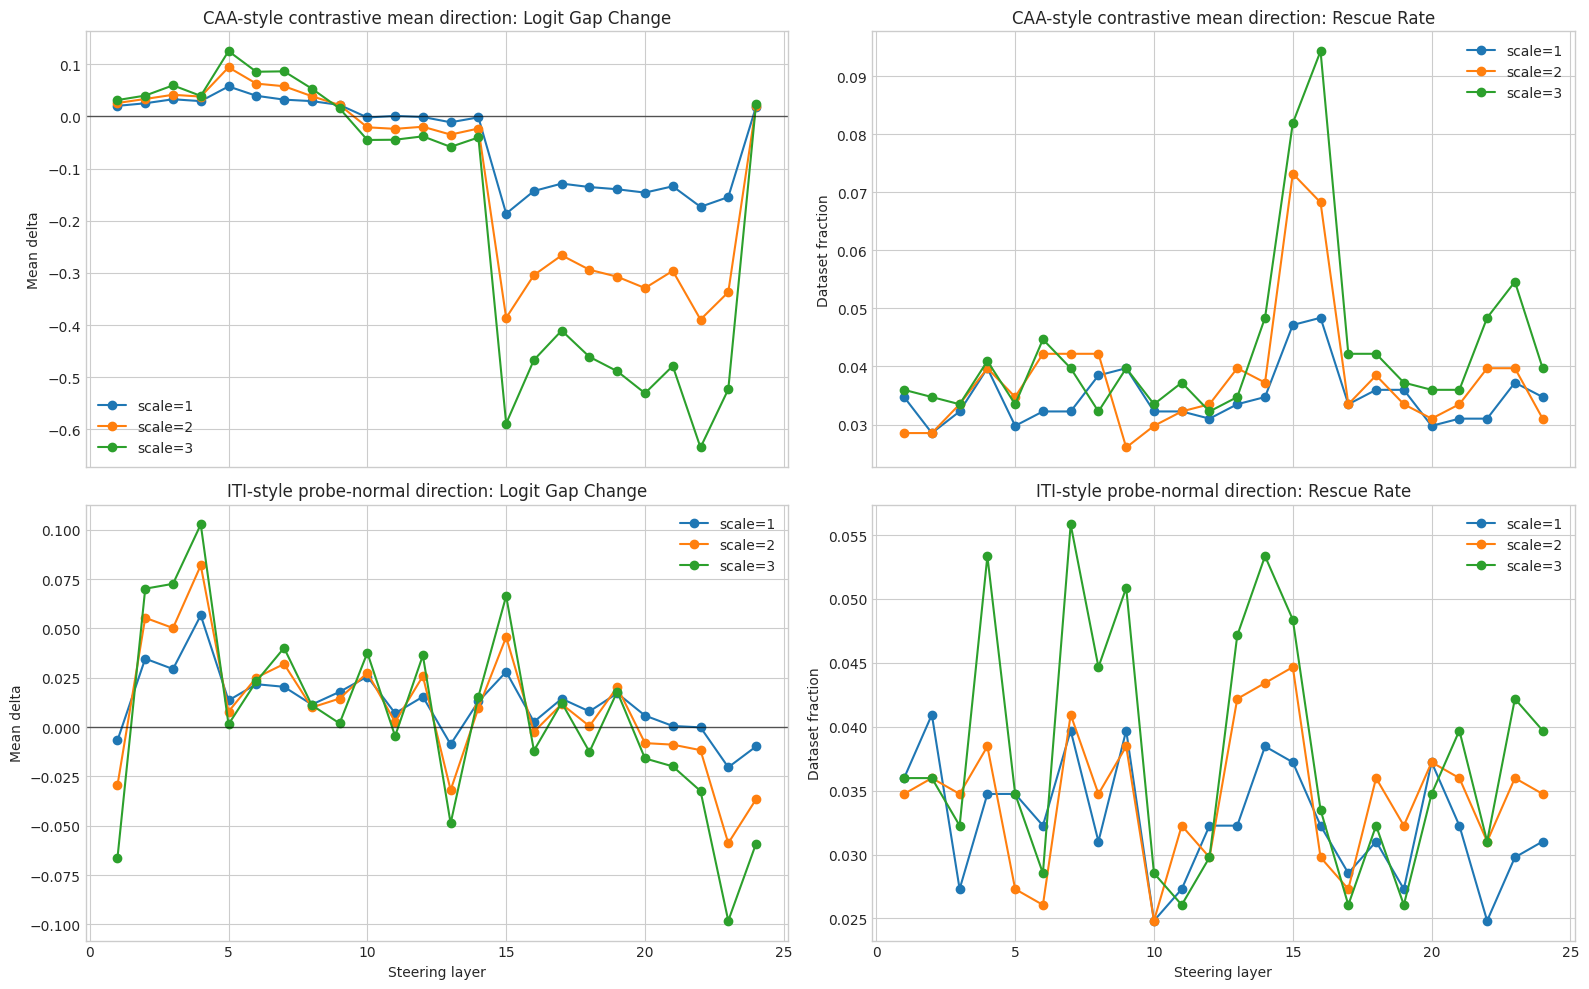

In [15]:
methods = steering_summary_by_scale["steering_method"].drop_duplicates().tolist()
fig, axes = plt.subplots(len(methods), 2, figsize=(16, 5 * len(methods)), sharex=True)
if len(methods) == 1:
    axes = np.array([axes])

for row_idx, method in enumerate(methods):
    part = steering_summary_by_scale.loc[steering_summary_by_scale["steering_method"].eq(method)]
    for steering_scale in sorted(part["steering_scale"].unique()):
        scale_part = part.loc[part["steering_scale"].eq(steering_scale)].sort_values("steering_layer_number")
        x = scale_part["steering_layer_number"].to_numpy()

        axes[row_idx, 0].plot(
            x,
            scale_part["mean_delta_true_answer_vs_best_other_logit_gap"],
            marker="o",
            label=f"scale={steering_scale:g}",
        )

        axes[row_idx, 1].plot(
            x,
            scale_part["rescue_rate"],
            marker="o",
            label=f"scale={steering_scale:g}",
        )

    axes[row_idx, 0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
    axes[row_idx, 0].set_ylabel("Mean delta")
    axes[row_idx, 0].set_title(f"{method}: Logit Gap Change")
    axes[row_idx, 0].legend()

    axes[row_idx, 1].set_ylabel("Dataset fraction")
    axes[row_idx, 1].set_title(f"{method}: Rescue Rate")
    axes[row_idx, 1].legend()

axes[-1, 0].set_xlabel("Steering layer")
axes[-1, 1].set_xlabel("Steering layer")
plt.tight_layout()
plt.show()


In [16]:
display(
    steering_summary_by_scale.sort_values(
        ["rescue_rate", "mean_delta_true_answer_vs_best_other_logit_gap"],
        ascending=[False, False],
    )
    .head(20)
    .round(4)
)


,steering_method,steering_scale,steering_layer_number,mean_delta_true_answer_vs_best_other_logit_gap,rescue_rate,prediction_change_rate,steered_mean_true_answer_vs_best_other_logit_gap
63,CAA-style contrastive mean direction,3.0,16,-0.4667,0.0943,0.1811,-2.0377
62,CAA-style contrastive mean direction,3.0,15,-0.5886,0.0819,0.1625,-2.1595
38,CAA-style contrastive mean direction,2.0,15,-0.3861,0.0732,0.1352,-1.9570
39,CAA-style contrastive mean direction,2.0,16,-0.3041,0.0682,0.1290,-1.8751
126,ITI-style probe-normal direction,3.0,7,0.0401,0.0558,0.1005,-1.5309
70,CAA-style contrastive mean direction,3.0,23,-0.5231,0.0546,0.1117,-2.0941
123,ITI-style probe-normal direction,3.0,4,0.1027,0.0533,0.1017,-1.4683
133,ITI-style probe-normal direction,3.0,14,0.0154,0.0533,0.1092,-1.5555
128,ITI-style probe-normal direction,3.0,9,0.0019,0.0509,0.0968,-1.5691
134,ITI-style probe-normal direction,3.0,15,0.0664,0.0484,0.0955,-1.5046


### Clean Steering Harm Control

The same steering directions are also applied to clean-correct evaluation traces. The purpose is to measure how often a corrective direction damages an already correct trajectory.


In [17]:
clean_steering_df = run_directional_steering_scan(
    eval_good_rows,
    steering_layer_numbers,
    steering_directions,
    STEERING_SCALES,
    STEERING_BATCH_SIZE,
    desc="clean steering control",
)

clean_steering_df = clean_steering_df.merge(
    eval_good_rows[[
        "example_id",
        "clean_prediction_idx",
        "clean_true_answer_vs_best_other_logit_gap",
        "clean_is_correct",
    ]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
clean_steering_df["delta_true_answer_vs_best_other_logit_gap"] = (
    clean_steering_df["steered_true_answer_vs_best_other_logit_gap"] - clean_steering_df["clean_true_answer_vs_best_other_logit_gap"]
)
clean_steering_df["prediction_changed"] = ~clean_steering_df["steered_prediction_idx"].eq(clean_steering_df["clean_prediction_idx"])
clean_steering_df["clean_correct_harmed"] = clean_steering_df["clean_is_correct"] & (~clean_steering_df["steered_is_correct"])

display(clean_steering_df.head())


clean steering control: 100%|██████████| 24/24 [45:54<00:00, 114.76s/it]


,example_id,steering_layer_number,steering_method,steering_scale,steered_prediction_idx,steered_true_answer_vs_best_other_logit_gap,steered_is_correct,clean_prediction_idx,clean_true_answer_vs_best_other_logit_gap,clean_is_correct,delta_true_answer_vs_best_other_logit_gap,prediction_changed,clean_correct_harmed
0,a7059f15c9a41e642c05358ee3bfdad5,1,CAA-style contrastive mean direction,1.0,1,3.125,True,1,2.375,True,0.750,False,False
1,ae67f1af6b3e31ab97be57aa2519b565,1,CAA-style contrastive mean direction,1.0,0,1.000,True,0,1.000,True,0.000,False,False
2,b8ede90d3c3d058c817d5ce9beb2227f,1,CAA-style contrastive mean direction,1.0,2,2.375,True,2,2.750,True,-0.375,False,False
3,f3b6be111df0899fd1a4e85fb3000b0e,1,CAA-style contrastive mean direction,1.0,3,1.000,True,3,1.375,True,-0.375,False,False
4,bfa81d23bf12dab0c90b6c76fbe2129f,1,CAA-style contrastive mean direction,1.0,4,1.000,True,4,0.875,True,0.125,False,False


In [18]:
clean_steering_summary_by_scale = (
    clean_steering_df.groupby(["steering_method", "steering_scale", "steering_layer_number"])
    .agg(
        mean_delta_true_answer_vs_best_other_logit_gap=("delta_true_answer_vs_best_other_logit_gap", "mean"),
        prediction_change_rate=("prediction_changed", "mean"),
        steered_accuracy=("steered_is_correct", "mean"),
        clean_correct_harm_rate=("clean_correct_harmed", "mean"),
    )
    .reset_index()
)

clean_steering_summary = (
    clean_steering_summary_by_scale.groupby(["steering_method", "steering_layer_number"])
    .agg(
        mean_delta_true_answer_vs_best_other_logit_gap_mean=("mean_delta_true_answer_vs_best_other_logit_gap", "mean"),
        mean_delta_true_answer_vs_best_other_logit_gap_std=("mean_delta_true_answer_vs_best_other_logit_gap", "std"),
        prediction_change_rate_mean=("prediction_change_rate", "mean"),
        prediction_change_rate_std=("prediction_change_rate", "std"),
        steered_accuracy_mean=("steered_accuracy", "mean"),
        steered_accuracy_std=("steered_accuracy", "std"),
        clean_correct_harm_rate_mean=("clean_correct_harm_rate", "mean"),
        clean_correct_harm_rate_std=("clean_correct_harm_rate", "std"),
    )
    .reset_index()
    .fillna(0.0)
)

display(clean_steering_summary_by_scale.round(4))
display(clean_steering_summary.round(4))


,steering_method,steering_scale,steering_layer_number,mean_delta_true_answer_vs_best_other_logit_gap,prediction_change_rate,steered_accuracy,clean_correct_harm_rate
0,CAA-style contrastive mean direction,1.0,1,-0.0149,0.0191,0.9809,0.0191
1,CAA-style contrastive mean direction,1.0,2,-0.0204,0.0221,0.9779,0.0221
2,CAA-style contrastive mean direction,1.0,3,-0.0224,0.0201,0.9799,0.0201
3,CAA-style contrastive mean direction,1.0,4,-0.0126,0.0191,0.9809,0.0191
4,CAA-style contrastive mean direction,1.0,5,-0.0592,0.0191,0.9809,0.0191
...,...,...,...,...,...,...,...
139,ITI-style probe-normal direction,3.0,20,0.0368,0.0181,0.9819,0.0181
140,ITI-style probe-normal direction,3.0,21,0.0467,0.0252,0.9748,0.0252
141,ITI-style probe-normal direction,3.0,22,0.0180,0.0382,0.9618,0.0382
142,ITI-style probe-normal direction,3.0,23,0.1105,0.0483,0.9517,0.0483


,steering_method,steering_layer_number,mean_delta_true_answer_vs_best_other_logit_gap_mean,mean_delta_true_answer_vs_best_other_logit_gap_std,prediction_change_rate_mean,prediction_change_rate_std,steered_accuracy_mean,steered_accuracy_std,clean_correct_harm_rate_mean,clean_correct_harm_rate_std
0,CAA-style contrastive mean direction,1,-0.0193,0.0044,0.0205,0.0042,0.9795,0.0042,0.0205,0.0042
1,CAA-style contrastive mean direction,2,-0.0393,0.0200,0.0211,0.0017,0.9789,0.0017,0.0211,0.0017
2,CAA-style contrastive mean direction,3,-0.0511,0.0307,0.0235,0.0042,0.9765,0.0042,0.0235,0.0042
3,CAA-style contrastive mean direction,4,-0.0138,0.0026,0.0215,0.0021,0.9785,0.0021,0.0215,0.0021
4,CAA-style contrastive mean direction,5,-0.1138,0.0529,0.0241,0.0044,0.9759,0.0044,0.0241,0.0044
5,CAA-style contrastive mean direction,6,-0.0706,0.0328,0.0221,0.0044,0.9779,0.0044,0.0221,0.0044
6,CAA-style contrastive mean direction,7,-0.0645,0.0314,0.0205,0.0065,0.9795,0.0065,0.0205,0.0065
7,CAA-style contrastive mean direction,8,-0.0362,0.0181,0.0211,0.0020,0.9789,0.0020,0.0211,0.0020
8,CAA-style contrastive mean direction,9,-0.0229,0.0060,0.0268,0.0077,0.9732,0.0077,0.0268,0.0077
9,CAA-style contrastive mean direction,10,0.0280,0.0183,0.0295,0.0051,0.9705,0.0051,0.0295,0.0051


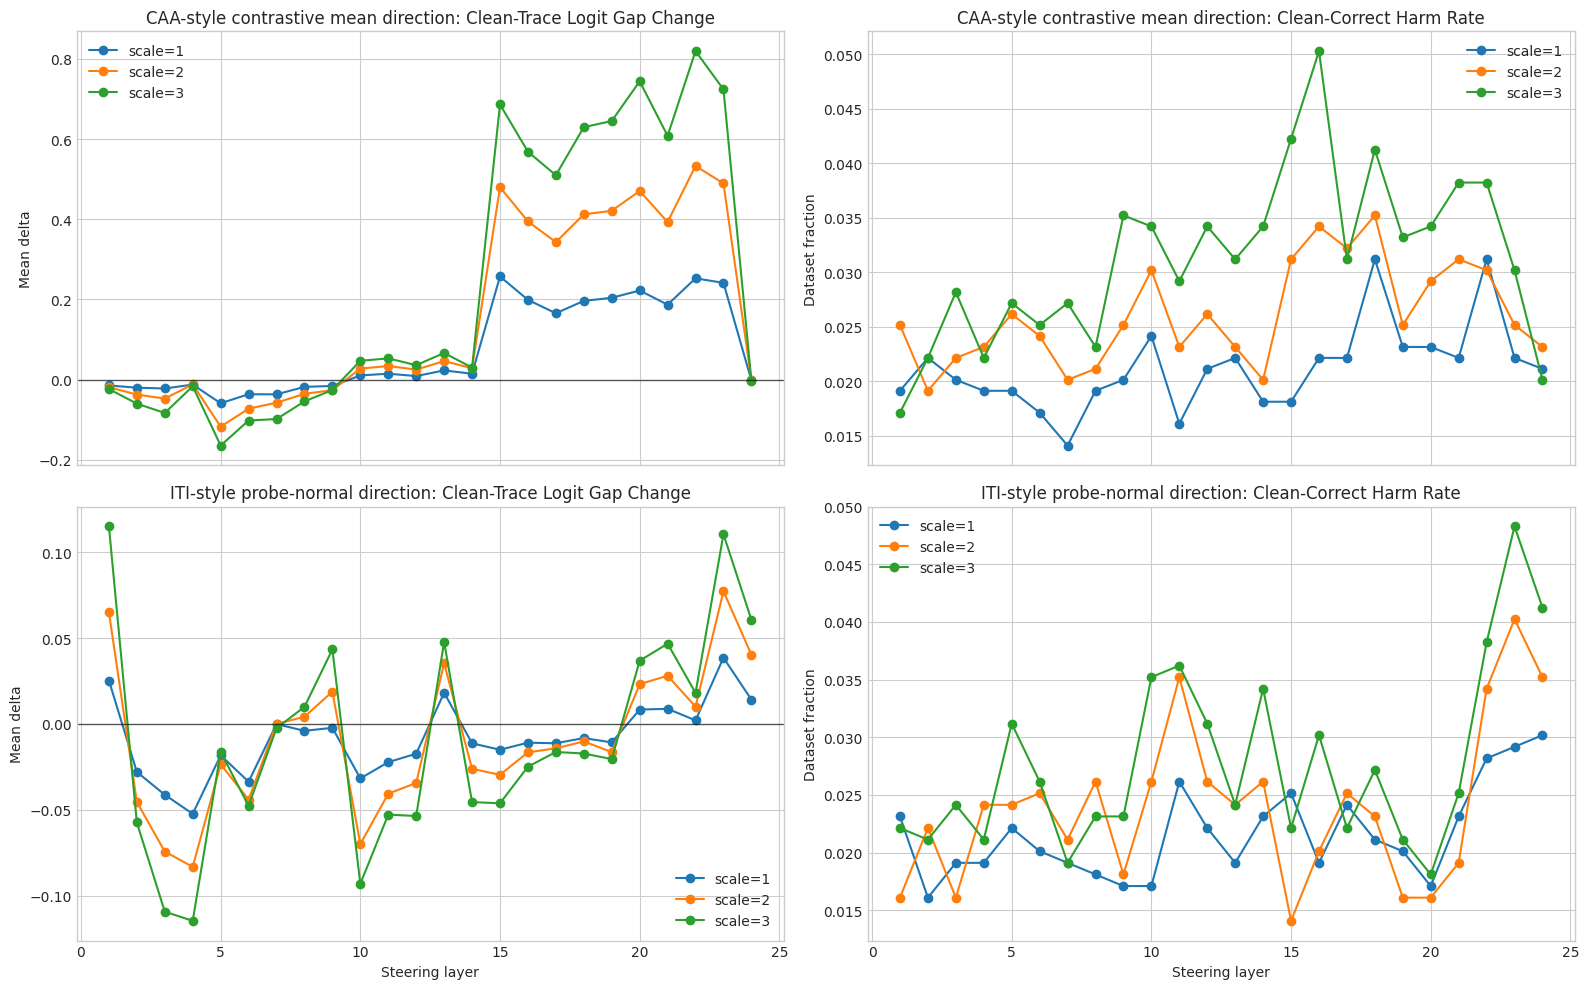

In [ ]:
methods = clean_steering_summary_by_scale["steering_method"].drop_duplicates().tolist()
fig, axes = plt.subplots(len(methods), 2, figsize=(16, 5 * len(methods)), sharex=True)
if len(methods) == 1:
    axes = np.array([axes])

for row_idx, method in enumerate(methods):
    part = clean_steering_summary_by_scale.loc[clean_steering_summary_by_scale["steering_method"].eq(method)]
    for steering_scale in sorted(part["steering_scale"].unique()):
        scale_part = part.loc[part["steering_scale"].eq(steering_scale)].sort_values("steering_layer_number")
        x = scale_part["steering_layer_number"].to_numpy()

        axes[row_idx, 0].plot(
            x,
            scale_part["mean_delta_true_answer_vs_best_other_logit_gap"],
            marker="o",
            label=f"scale={steering_scale:g}",
        )
        axes[row_idx, 1].plot(
            x,
            scale_part["clean_correct_harm_rate"],
            marker="o",
            label=f"scale={steering_scale:g}",
        )

    axes[row_idx, 0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
    axes[row_idx, 0].set_ylabel("Mean delta")
    axes[row_idx, 0].set_title(f"{method}: Clean-Trace Logit Gap Change")
    axes[row_idx, 0].legend()

    axes[row_idx, 1].set_ylabel("Dataset fraction")
    axes[row_idx, 1].set_title(f"{method}: Clean-Correct Harm Rate")
    axes[row_idx, 1].legend()

axes[-1, 0].set_xlabel("Steering layer")
axes[-1, 1].set_xlabel("Steering layer")
plt.tight_layout()
plt.show()

### Recovery Minus Harm

Final summary of directional benefit versus damage.

- 
ecovery_minus_harm = rescue_rate - clean_correct_harm_rate
- 
_incorrect_examples_saved: incorrect clean traces turned correct by steering
- 
_clean_correct_examples_lost: correct clean traces turned incorrect by steering


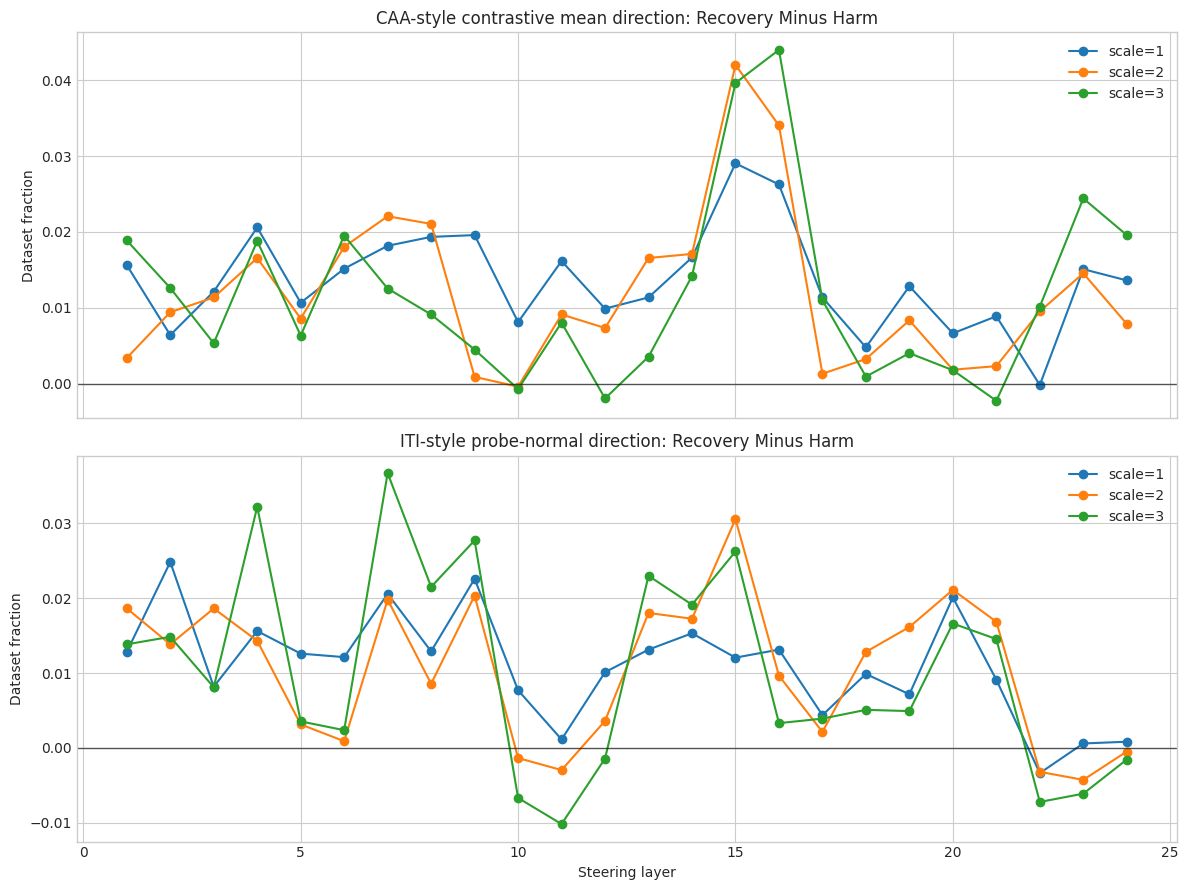

,steering_method,steering_scale,steering_layer_number,rescue_rate,n_incorrect_examples_saved,clean_correct_harm_rate,n_clean_correct_examples_lost,recovery_minus_harm
63,CAA-style contrastive mean direction,3.0,16,0.0943,76,0.0503,50,0.0440
38,CAA-style contrastive mean direction,2.0,15,0.0732,59,0.0312,31,0.0420
62,CAA-style contrastive mean direction,3.0,15,0.0819,66,0.0423,42,0.0396
126,ITI-style probe-normal direction,3.0,7,0.0558,45,0.0191,19,0.0367
39,CAA-style contrastive mean direction,2.0,16,0.0682,55,0.0342,34,0.0340
...,...,...,...,...,...,...,...,...
118,ITI-style probe-normal direction,2.0,23,0.0360,29,0.0402,40,-0.0043
142,ITI-style probe-normal direction,3.0,23,0.0422,34,0.0483,48,-0.0061
129,ITI-style probe-normal direction,3.0,10,0.0285,23,0.0352,35,-0.0067
141,ITI-style probe-normal direction,3.0,22,0.0310,25,0.0382,38,-0.0072


In [ ]:
recovery_counts = (
    steering_df.groupby(["steering_method", "steering_scale", "steering_layer_number"])
    .agg(
        rescue_rate=("became_correct", "mean"),
        n_incorrect_examples_saved=("became_correct", "sum"),
    )
    .reset_index()
)

harm_counts = (
    clean_steering_df.groupby(["steering_method", "steering_scale", "steering_layer_number"])
    .agg(
        clean_correct_harm_rate=("clean_correct_harmed", "mean"),
        n_clean_correct_examples_lost=("clean_correct_harmed", "sum"),
    )
    .reset_index()
)

recovery_minus_harm_summary = (
    recovery_counts.merge(
        harm_counts,
        on=["steering_method", "steering_scale", "steering_layer_number"],
        how="inner",
        validate="one_to_one",
    )
    .assign(
        recovery_minus_harm=lambda df: df["rescue_rate"] - df["clean_correct_harm_rate"],
        n_incorrect_examples_saved=lambda df: df["n_incorrect_examples_saved"].astype(int),
        n_clean_correct_examples_lost=lambda df: df["n_clean_correct_examples_lost"].astype(int),
    )
)

methods = recovery_minus_harm_summary["steering_method"].drop_duplicates().tolist()
fig, axes = plt.subplots(len(methods), 1, figsize=(12, 4.5 * len(methods)), sharex=True)
if len(methods) == 1:
    axes = np.array([axes])

for row_idx, method in enumerate(methods):
    part = recovery_minus_harm_summary.loc[recovery_minus_harm_summary["steering_method"].eq(method)]
    for steering_scale in sorted(part["steering_scale"].unique()):
        scale_part = part.loc[part["steering_scale"].eq(steering_scale)].sort_values("steering_layer_number")
        axes[row_idx].plot(
            scale_part["steering_layer_number"],
            scale_part["recovery_minus_harm"],
            marker="o",
            label=f"scale={steering_scale:g}",
        )
    axes[row_idx].axhline(0.0, color="black", linewidth=1, alpha=0.6)
    axes[row_idx].set_ylabel("Dataset fraction")
    axes[row_idx].set_title(f"{method}: Recovery Minus Harm")
    axes[row_idx].legend()

axes[-1].set_xlabel("Steering layer")
plt.tight_layout()
plt.show()

display(
    recovery_minus_harm_summary.sort_values(
        ["recovery_minus_harm", "n_incorrect_examples_saved", "n_clean_correct_examples_lost"],
        ascending=[False, False, True],
    )
    .round(4)
)